# 🌾 Rice Variety Classification with CNN & Transfer Learning

**Pipeline overview**

| # | Step |
|---|------|
| 1 | Import libraries |
| 2 | Load dataset from local folder |
| 3 | Preview 3–5 images per class |
| 4 | Train / validation / test split (stratified random split) |
| 5 | Class distribution plot |
| 6 | Data preprocessing (augmentation) |
| 7 | CNN model architecture |
| 8 | Compile & fit (ModelCheckpoint + EarlyStopping) |
| 9 | Training/validation accuracy & loss curves |
| 10 | Confusion matrix, F1, accuracy, recall, precision |
| 11 | Save model: SavedModel, TF-Lite, TFJS |
| 12 | Inference with the saved model |


## 1. Import Libraries

In [1]:
# imports

import os, glob, shutil, random, pathlib, json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image
from skimage import filters, exposure

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split

from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Load Dataset from Local Folder

5-class dataset (Arborio, Basmati, Ipsala, Jasmine, Karacadag)

In [2]:
# Point at the local dataset folder
PROJECT_ROOT = pathlib.Path(r"D:\Kuliah\coding\rice-collection-classification-using-cnn-arc")
DATA_DIR = PROJECT_ROOT / "Rice_Image_Dataset"

class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Data directory : {DATA_DIR}")
print(f"Number of classes: {len(class_names)}")
print("Classes:", class_names)

Data directory : D:\Kuliah\coding\rice-collection-classification-using-cnn-arc\Rice_Image_Dataset
Number of classes: 5
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


## 3. Preview Sample Images per Class

In [3]:
N_SAMPLES = 5
fig, axes = plt.subplots(len(class_names), N_SAMPLES, figsize=(N_SAMPLES * 2.2, len(class_names) * 2.2))

for row, cls in enumerate(class_names):
    cls_dir = DATA_DIR / cls
    files = list(cls_dir.glob("*"))
    sample_files = random.sample(files, min(N_SAMPLES, len(files)))
    for col in range(N_SAMPLES):
        ax = axes[row, col]
        if col < len(sample_files):
            img = Image.open(sample_files[col]).convert("RGB")
            ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.text(-0.1, 0.5, cls, fontsize=10, rotation=90,
                     va="center", ha="center", transform=ax.transAxes)

plt.suptitle("Sample images per class", fontsize=14)
plt.tight_layout()
plt.show()


<Figure size 1100x1100 with 25 Axes>

## 4. Train / Validation / Test Split

70% train / 15% validation / 15% test


In [4]:
filepaths, labels = [], []
for cls in class_names:
    for f in (DATA_DIR / cls).glob("*"):
        filepaths.append(str(f))
        labels.append(cls)

df = pd.DataFrame({"filepath": filepaths, "label": labels})
print(f"Total images: {len(df)}")

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

Total images: 10000
Train: 7000  Val: 1500  Test: 1500


In [5]:
# tf.data pipelines
AUTOTUNE = tf.data.AUTOTUNE
label_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)

def _load_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    label = tf.one_hot(label, num_classes)
    return img, label

def make_dataset(dframe, shuffle=False, batch_size=BATCH_SIZE):
    paths = dframe["filepath"].values
    lbls = dframe["label"].map(label_to_idx).values
    ds = tf.data.Dataset.from_tensor_slices((paths, lbls))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dframe), seed=SEED)
    ds = ds.map(_load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds_raw = make_dataset(train_df, shuffle=True)
val_ds_raw   = make_dataset(val_df)
test_ds_raw  = make_dataset(test_df)


## 5. Class Distribution Plot

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2692\1398531004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="label", order=order, palette="viridis", ax=axes)


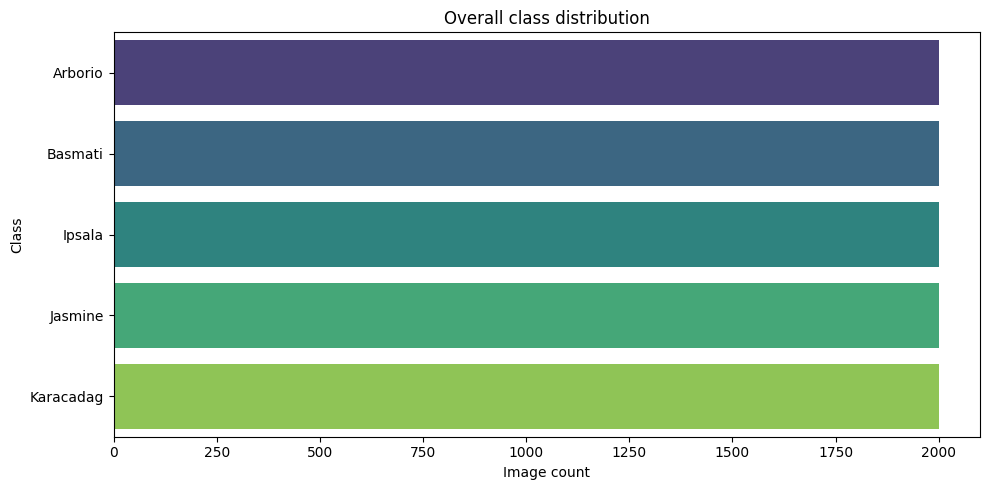

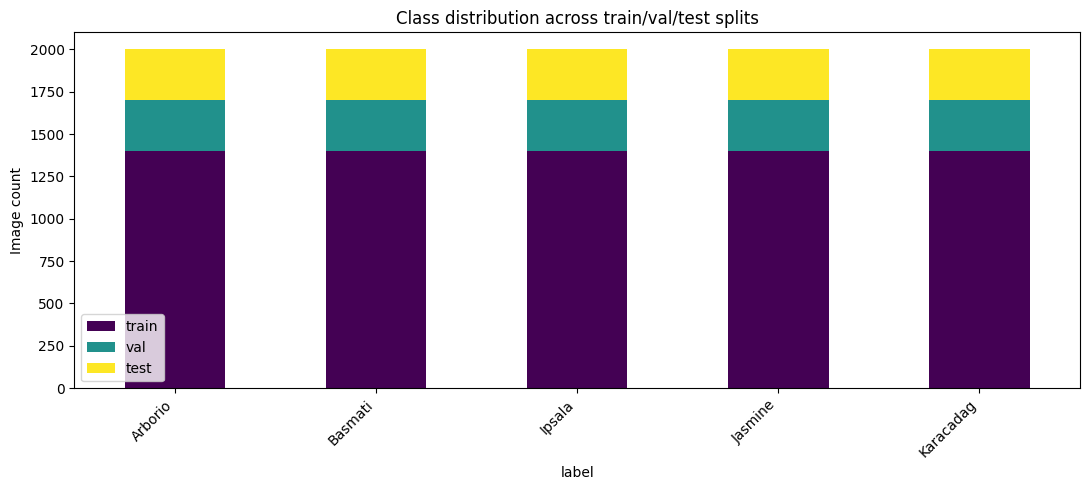

           train  val  test
label                      
Arborio     1400  300   300
Basmati     1400  300   300
Ipsala      1400  300   300
Jasmine     1400  300   300
Karacadag   1400  300   300


In [6]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))
order = df["label"].value_counts().index
sns.countplot(data=df, y="label", order=order, palette="viridis", ax=axes)
axes.set_title("Overall class distribution")
axes.set_xlabel("Image count")
axes.set_ylabel("Class")
plt.tight_layout()
plt.show()

split_counts = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "val":   val_df["label"].value_counts(),
    "test":  test_df["label"].value_counts(),
}).fillna(0).astype(int)
split_counts.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="viridis")
plt.title("Class distribution across train/val/test splits")
plt.ylabel("Image count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(split_counts)


## 6. Data Preprocessing


In [7]:
# Data Augmentation

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomRotation(0.15),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomCrop(int(IMG_SIZE[0] * 0.9), int(IMG_SIZE[1] * 0.9)),
    layers.Resizing(*IMG_SIZE),
], name="data_augmentation")

def random_shear(image, shear_range=0.15):
    shear = tf.random.uniform([], -shear_range, shear_range)
    image = tf.expand_dims(image, 0)
    transform = [1.0, shear, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
    image = tf.raw_ops.ImageProjectiveTransformV3(
        images=image, transforms=[transform], output_shape=tf.shape(image)[1:3],
        interpolation="BILINEAR", fill_mode="REFLECT", fill_value=0.0)
    return tf.squeeze(image, 0)

def random_resolution_drop(image, prob=0.3, factor=0.5):
    if tf.random.uniform([]) < prob:
        small = tf.image.resize(image, [int(IMG_SIZE[0]*factor), int(IMG_SIZE[1]*factor)])
        image = tf.image.resize(small, IMG_SIZE)
    return image


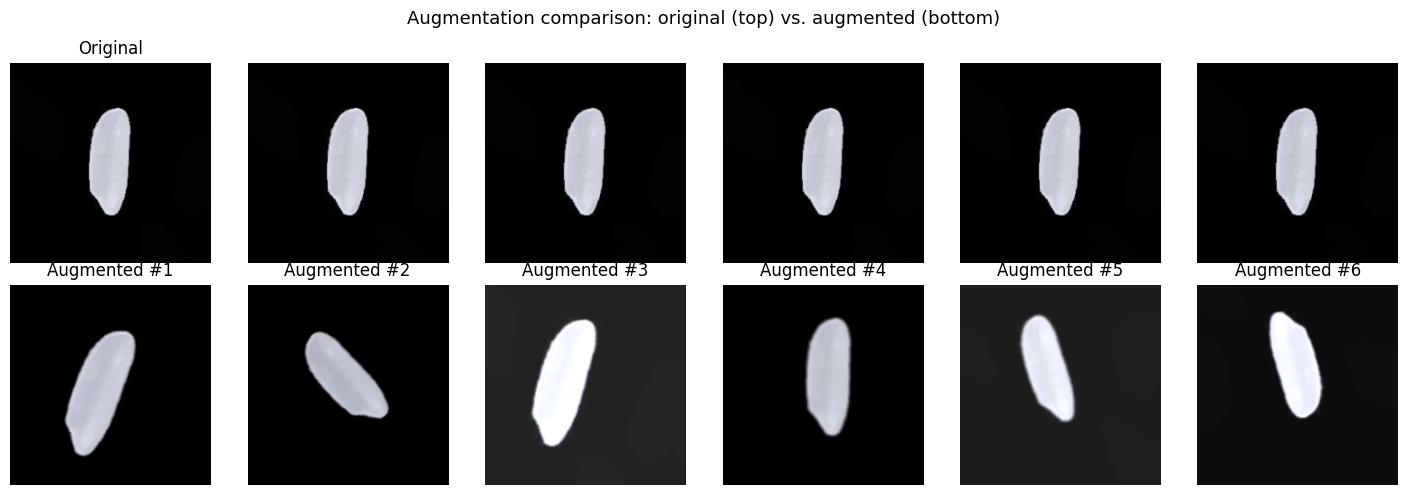

In [8]:
# Before/after comparison of augmentation 

sample_path = df.sample(1, random_state=SEED)["filepath"].values[0]
orig = tf.image.resize(tf.io.decode_image(tf.io.read_file(sample_path), channels=3,
                                           expand_animations=False), IMG_SIZE)
orig = tf.cast(orig, tf.float32)

n_variants = 6
fig, axes = plt.subplots(2, n_variants, figsize=(n_variants * 2.4, 5))

for i in range(n_variants):
    axes[0, i].imshow(orig.numpy().astype("uint8"))
    axes[0, i].set_title("Original" if i == 0 else "")
    axes[0, i].axis("off")

    aug = data_augmentation(tf.expand_dims(orig, 0), training=True)[0]
    aug = random_shear(aug)
    aug = random_resolution_drop(aug)
    aug = tf.clip_by_value(aug, 0, 255)
    axes[1, i].imshow(aug.numpy().astype("uint8"))
    axes[1, i].set_title(f"Augmented #{i+1}")
    axes[1, i].axis("off")

plt.suptitle("Augmentation comparison: original (top) vs. augmented (bottom)", fontsize=13)
plt.tight_layout()
plt.show()


In [9]:
# Wire augmentation into the training pipeline (val/test stay unaugmented)
train_ds = train_ds_raw.map(lambda x, y: (data_augmentation(x, training=True), y),
                             num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds_raw.prefetch(AUTOTUNE)
test_ds = test_ds_raw.prefetch(AUTOTUNE)


## 7. CNN Model Architecture

In [10]:
def build_baseline_cnn(input_shape=(*IMG_SIZE, 3), num_classes=num_classes):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="baseline_cnn")

baseline_model = build_baseline_cnn()
baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,413 (1.74 MB)

 Trainable params: 456,453 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## 8. Compile & Fit

In [11]:
# callbacks for training

class StopAtAccuracy(callbacks.Callback):
    def __init__(self, target=0.95, monitor="val_accuracy"):
        super().__init__()
        self.target = target
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        value = logs.get(self.monitor)
        if value is not None and value >= self.target:
            print(f"\n{self.monitor} reached {value:.4f} >= {self.target} — stopping training.")
            self.model.stop_training = True

In [12]:
# Compile and train the baseline model 

EPOCHS = 30

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

os.makedirs("checkpoints", exist_ok=True)

cb_list = [
    callbacks.ModelCheckpoint("checkpoints/baseline_best.keras", monitor="val_accuracy", save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0),
]
    
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list
)


Epoch 1/30


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


219/219 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.7566 - loss: 0.6472 - val_accuracy: 0.2500 - val_loss: 6.2233
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.8396 - loss: 0.4076 - val_accuracy: 0.9593 - val_loss: 0.1529
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.8761 - loss: 0.3239 - val_accuracy: 0.7227 - val_loss: 0.6598
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.8861 - loss: 0.2873 - val_accuracy: 0.8640 - val_loss: 0.3047
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.9009 - loss: 0.2470 - val_accuracy: 0.2367 - val_loss: 5.7139
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.9190 - loss: 0.2106 - val_accuracy: 0.5793 - val_loss: 1.6006
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.9283 - loss: 0.1859 - val_accuracy: 0.6333 - val_loss: 0.8963
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - accuracy: 0.9443 - loss: 0.1548 - val_accuracy: 0.908

## 9. Training vs. Validation Accuracy & Loss

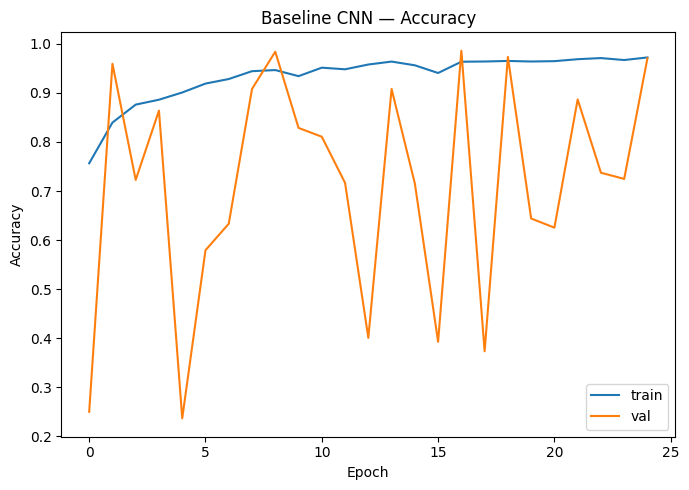

In [13]:
# Plot training vs. validation accuracy
def plot_accuracy(hist, title_prefix=""):
    plt.figure(figsize=(7, 5))
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"{title_prefix}Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_accuracy(history, title_prefix="Baseline CNN — ")


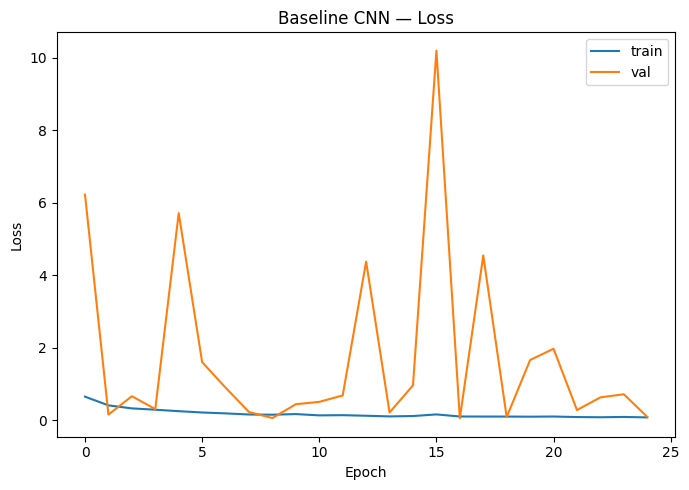

In [14]:
# Plot training vs. validation loss
def plot_loss(hist, title_prefix=""):
    plt.figure(figsize=(7, 5))
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"{title_prefix}Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_loss(history, title_prefix="Baseline CNN — ")


## 10. Confusion Matrix & Classification Metrics

--- Baseline CNN ---
Accuracy : 0.9760
Precision: 0.9773 (macro)
Recall   : 0.9760 (macro)
F1-score : 0.9760 (macro)

              precision    recall  f1-score   support

     Arborio       0.96      0.99      0.98       300
     Basmati       1.00      0.93      0.96       300
      Ipsala       1.00      1.00      1.00       300
     Jasmine       0.93      1.00      0.96       300
   Karacadag       1.00      0.96      0.98       300

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



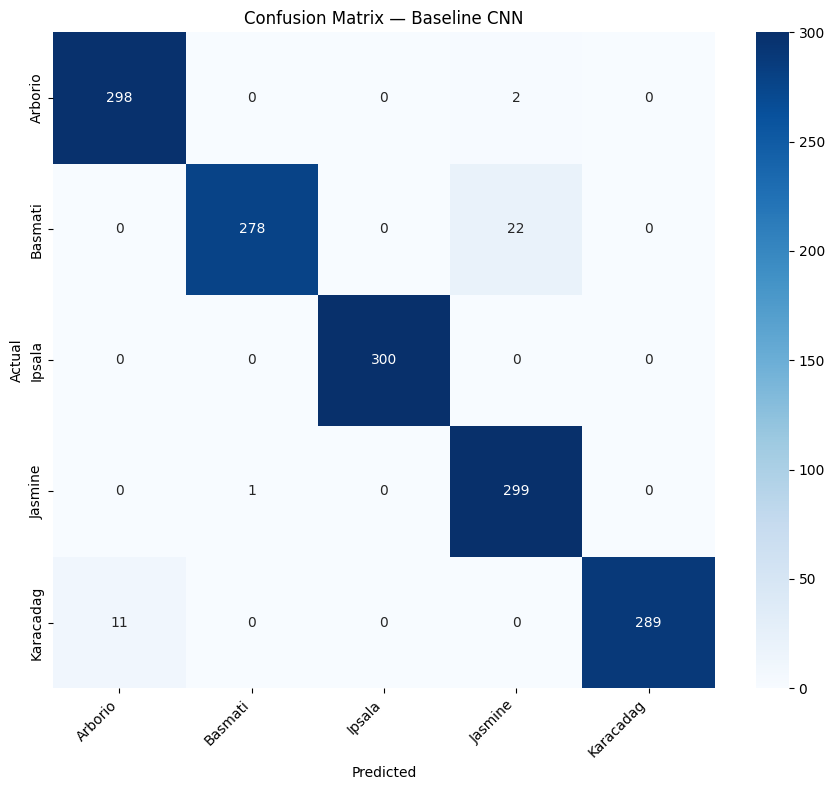

In [15]:
# Evaluate on the held-out test set: confusion matrix + accuracy/precision/recall/F1
def evaluate_model(model, dataset, class_names, title=""):
    y_true, y_pred = [], []
    for images, labels_batch in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels_batch.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"--- {title} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f} (macro)")
    print(f"Recall   : {rec:.4f} (macro)")
    print(f"F1-score : {f1:.4f} (macro)")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {title}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

baseline_metrics = evaluate_model(baseline_model, test_ds, class_names, title="Baseline CNN")


In [16]:
# Automated over/underfitting diagnosis from the train/val curves
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
gap = final_train_acc - final_val_acc

print(f"Final train accuracy: {final_train_acc:.4f}")
print(f"Final val accuracy  : {final_val_acc:.4f}")
print(f"Gap (train - val)   : {gap:.4f}")

if gap > 0.10:
    print("\nDiagnosis: OVERFITTING. No dropout/L2/early-stopping are active in this "
          "pipeline version — consider re-adding one of those, or more augmentation, if this fires.")
elif final_val_acc < 0.80:
    print("\nDiagnosis: UNDERFITTING. Recommend: transfer learning, longer training, LR tuning.")
else:
    print("\nDiagnosis: reasonably balanced fit.")


Final train accuracy: 0.9723
Final val accuracy  : 0.9707
Gap (train - val)   : 0.0016

Diagnosis: reasonably balanced fit.


## 11. SavedModel, TF-Lite, TFJS

In [17]:
# SavedModel format
best_model = keras.models.load_model("checkpoints/baseline_best.keras")

saved_model_dir = "saved_model"
best_model.export(saved_model_dir)
print(f"SavedModel exported to: {saved_model_dir}")

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2155008810000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155008817680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155008808080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155077038544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155008817104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155008817296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155077041424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155077036816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155077037200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155077038928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2155077036432: TensorSpec(shape=(), dt

In [18]:
# TF-Lite 
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

os.makedirs("tflite", exist_ok=True)

tflite_path = "tflite/model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

label_path = "tflite/label.txt"
with open(label_path, "w") as f:
    f.write("\n".join(class_names))

print(f"TF-Lite model saved to: {tflite_path}  ({len(tflite_model)/1e6:.2f} MB)")
print(f"Labels saved to: {label_path}")

TF-Lite model saved to: tflite/model.tflite  (0.48 MB)
Labels saved to: tflite/label.txt


In [37]:
!tfjs_env\Scripts\tensorflowjs_converter --input_format=tf_saved_model saved_model tfjs_model
print("Files:", sorted(os.listdir("tfjs_model")))

Writing weight file tfjs_model\model.json...
Files: ['group1-shard1of1.bin', 'model.json']


I0000 00:00:1787217946.779471   33576 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787217948.902401   33576 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

I0000 00:00:1787217951.438941   33576 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787217951.648668   33576 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capabil

In [38]:
# Save class-name mapping for inference-time decoding
with open("class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)
print("class_names.json saved:", class_names)


class_names.json saved: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


## 12. Inference with the Saved Model (TF-Lite)

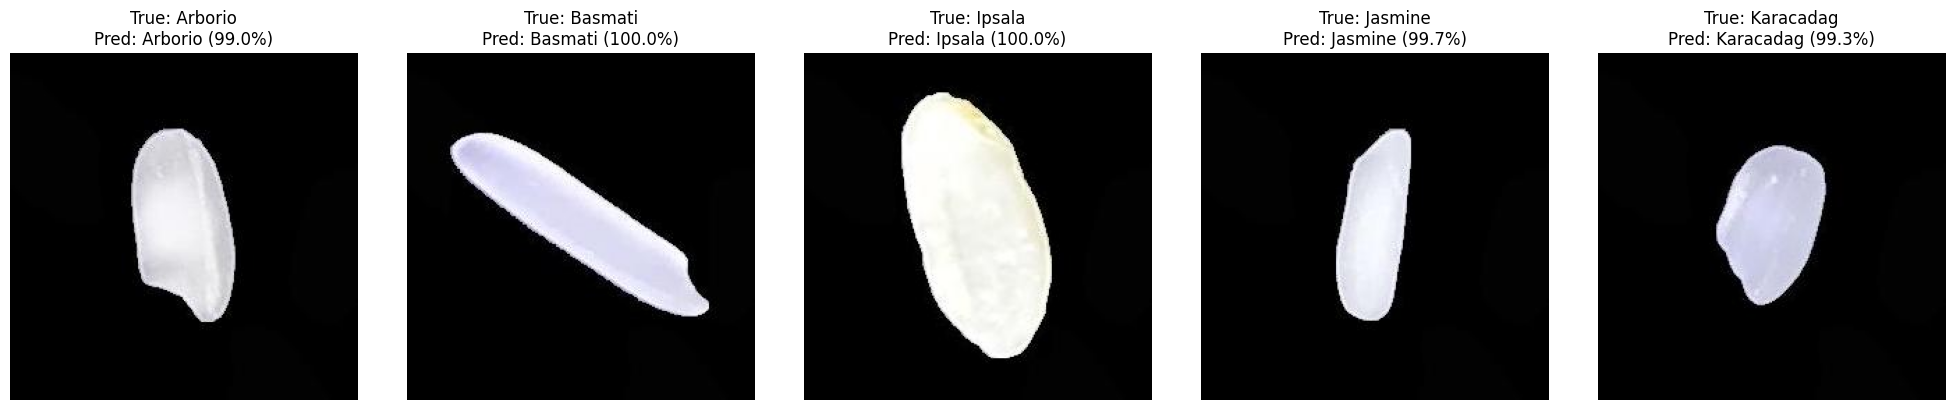

Accuracy on this sample: 5/5

✓ True: Arborio    | Predicted: Arborio    | Confidence: 99.04%
     Arborio        : 99.04%
     Ipsala         :  0.39%
     Jasmine        :  0.39%
     Karacadag      :  0.17%
     Basmati        :  0.00%

✓ True: Basmati    | Predicted: Basmati    | Confidence: 100.00%
     Basmati        : 100.00%
     Jasmine        :  0.00%
     Ipsala         :  0.00%
     Arborio        :  0.00%
     Karacadag      :  0.00%

✓ True: Ipsala     | Predicted: Ipsala     | Confidence: 100.00%
     Ipsala         : 100.00%
     Arborio        :  0.00%
     Basmati        :  0.00%
     Karacadag      :  0.00%
     Jasmine        :  0.00%

✓ True: Jasmine    | Predicted: Jasmine    | Confidence: 99.65%
     Jasmine        : 99.65%
     Arborio        :  0.20%
     Basmati        :  0.15%
     Ipsala         :  0.00%
     Karacadag      :  0.00%

✓ True: Karacadag  | Predicted: Karacadag  | Confidence: 99.33%
     Karacadag      : 99.33%
     Arborio        :  0.64%
    

In [39]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
results = []

for ax, cls in zip(axes, class_names):
    sample_path = test_df[test_df["label"] == cls].sample(1, random_state=SEED)["filepath"].values[0]

    img = Image.open(sample_path).convert("RGB").resize(IMG_SIZE)
    arr = np.expand_dims(np.array(img).astype("float32"), axis=0)
    preds = best_model.predict(arr, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_label, confidence = class_names[pred_idx], preds[pred_idx]

    ax.imshow(Image.open(sample_path))
    ax.axis("off")
    ax.set_title(f"True: {cls}\nPred: {pred_label} ({confidence*100:.1f}%)")

    results.append({
        "true_label": cls,
        "pred_label": pred_label,
        "confidence": confidence,
        "correct": cls == pred_label,
        "all_probs": preds
    })

plt.tight_layout()
plt.show()

print(f"Accuracy on this sample: {sum(r['correct'] for r in results)}/{len(results)}\n")

for r in results:
    status = "✓" if r["correct"] else "✗"
    print(f"{status} True: {r['true_label']:10s} | Predicted: {r['pred_label']:10s} | Confidence: {r['confidence']*100:5.2f}%")
    for c, p in sorted(zip(class_names, r["all_probs"]), key=lambda x: -x[1]):
        print(f"     {c:15s}: {p*100:5.2f}%")
    print()